In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
df = df.drop(columns=[
    "company",                  # Too many NaN
    "agent",                    # Agent's ID so not meaningful variable
    "reservation_status",       # outcome information (leak)
    "reservation_status_date"   # outcome date (leak)
])

In [10]:
# Fill NaN values
df["country"] = df["country"].fillna("Unknown")

In [17]:
# Drop duplicates
df = df.drop_duplicates()

## EDA

In [18]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87106.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000,87110.000000
mean,0.272770,79.727563,2016.210527,26.836666,15.815038,1.005418,2.625577,1.875927,0.138900,0.010837,0.039192,0.030238,0.184594,0.272276,0.731994,106.368301,0.084502,0.699977
std,0.445386,85.944230,0.685975,13.674381,8.835223,1.031590,2.051753,0.626816,0.456279,0.113682,0.194052,0.369397,1.734702,0.728030,9.866733,55.047502,0.281954,0.832241
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


(array([5.2203e+04, 1.7293e+04, 1.0676e+04, 4.3260e+03, 1.9000e+03,
        3.2400e+02, 1.5500e+02, 4.6000e+01, 1.4000e+01, 2.0000e+00]),
 array([  0. ,  73.7, 147.4, 221.1, 294.8, 368.5, 442.2, 515.9, 589.6,
        663.3, 737. ]),
 <BarContainer object of 10 artists>)

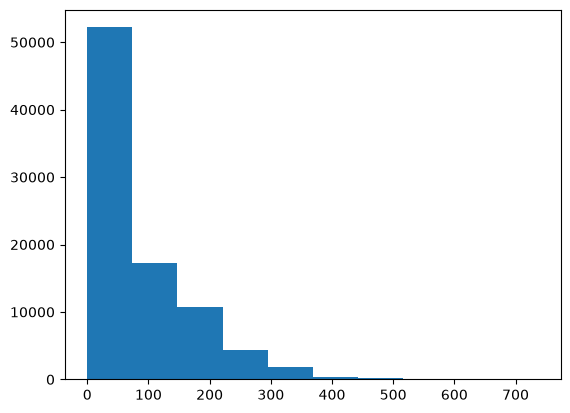

In [32]:
# Check skewness
plt.hist(df["lead_time"])

Many columns are skewed and will keep it mind during model creation.

In [ ]:
# Check for outliers
df.sort_values("adults", ascending=False).head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
2173,Resort Hotel,1,338,2015,October,41,4,2,0,55,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
1539,Resort Hotel,1,304,2015,September,36,3,0,3,40,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
1917,Resort Hotel,1,349,2015,September,39,21,1,3,27,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
1962,Resort Hotel,1,352,2015,September,39,24,1,3,27,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
2164,Resort Hotel,1,361,2015,October,40,3,2,5,26,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
1587,Resort Hotel,1,333,2015,September,36,5,2,5,26,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
1884,Resort Hotel,1,347,2015,September,38,19,2,5,26,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
2003,Resort Hotel,1,354,2015,September,39,26,2,5,26,...,0,A,A,0,No Deposit,0,Group,0.0,0,0
1752,Resort Hotel,1,340,2015,September,37,12,2,5,26,...,0,A,A,0,No Deposit,0,Group,0.0,0,0


Many columns large values don't seem to be outliers.

In [ ]:
# Removes negative hotel room price
df = df[df["adr"] >= 0]

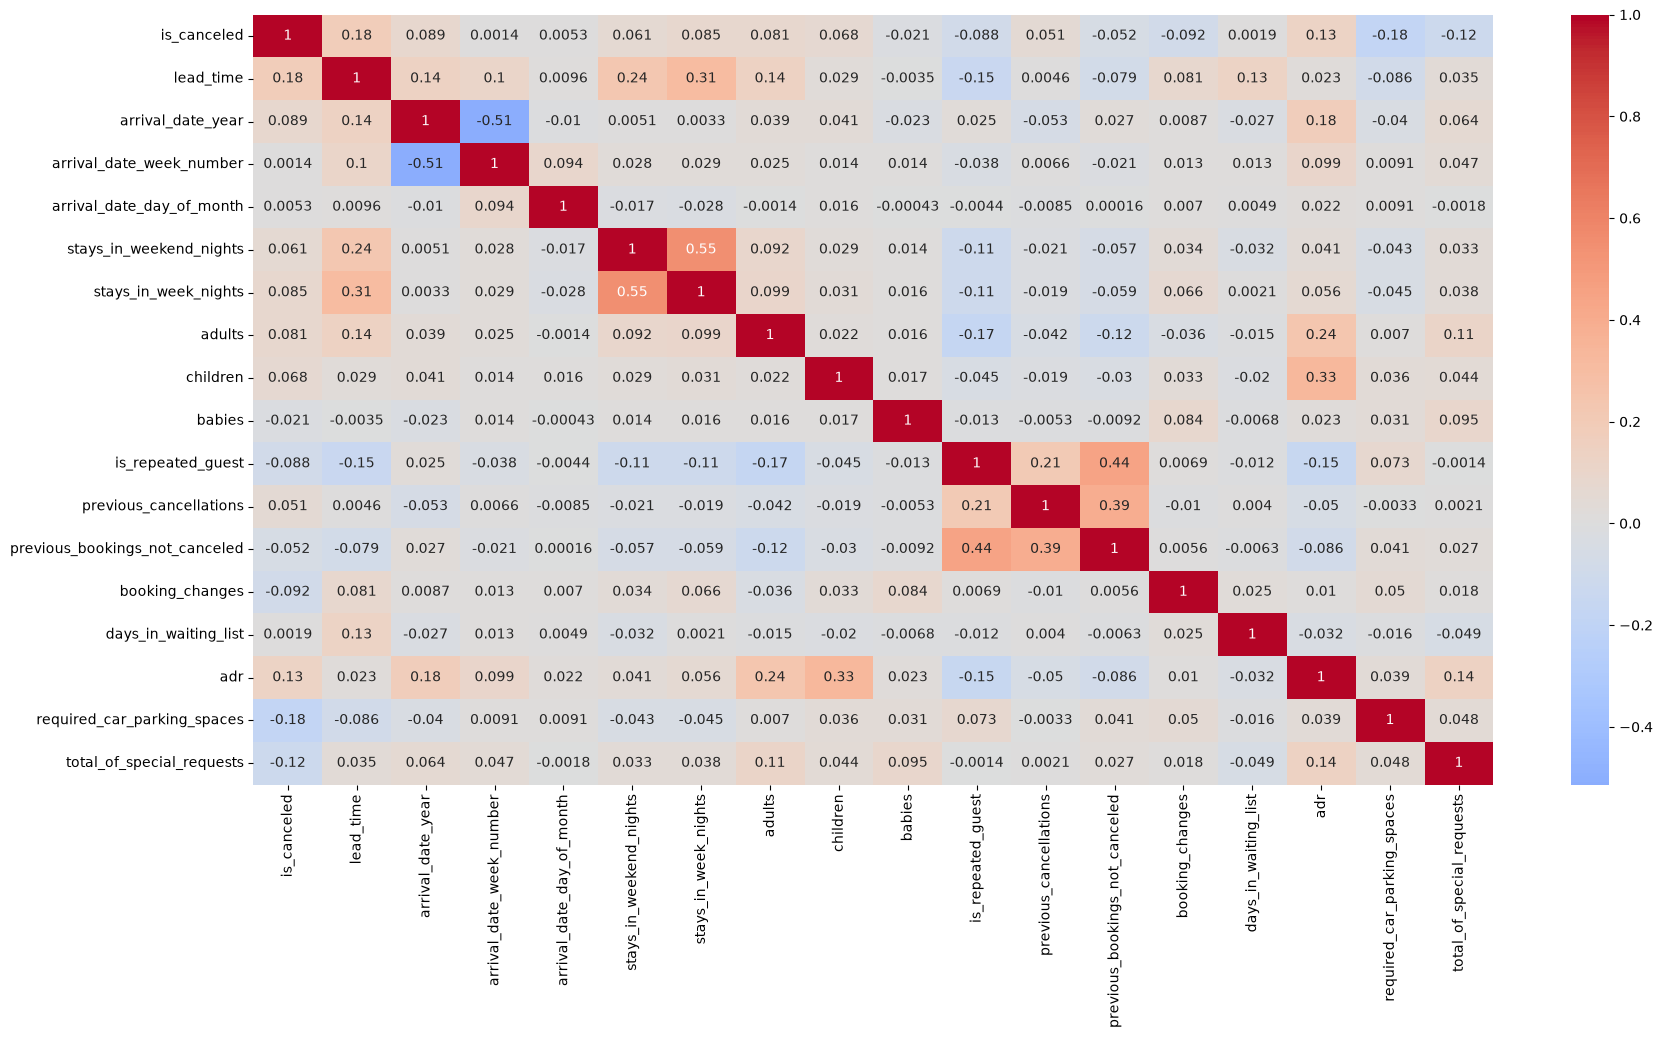

In [40]:
# Correlation
corr = df.corr(numeric_only=True)

plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

Nothing strongly correlated.

In [ ]:
df.to_csv("data/hotel_bookings_clean.csv", index=False)